In [1]:
!pip install ankh biopython torch transformers datasets scipy pandas blosum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.5 MB/s eta 0:00:00
  Created wheel for sentencepiece: filename=sentencepiece-0.1.99-cp312-cp312-linux_x86_64.whl size=1266901 sha256=d9e6eb4edbb5db2db9bcd3de813189d0994da81365c46dca94f71541163451d4
  Stored in directory: /root/.cache/pip/wheels/e0/8c/e0/65e33b1f4b8462dfc537a0cac02e5c03e1207564c300e4bde5
Successfully built sentencepiece
  Attempting uninstall: sentencepiece
    Found existing installation: sentencepie

In [3]:
import importlib
import e_score_quick_start as escore

importlib.reload(escore)

print("Inicializando modelo Ankh...")
model, tokenizer = escore.Ankh_initialize()
print("Modelo listo.")

Inicializando modelo Ankh...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Modelo listo.


In [12]:

# import e_score_quick_start as escore

#print("Inicializando modelo Ankh...")
#model, tokenizer = escore.Ankh_initialize()
#print("Modelo listo.")

#Secuencias del paper para probar
seq1 = "CPHALHRVCGSDGETYSNPCTLNCAKFNGKPELVKVHDGPC"
seq2 = "CTMEYFPLCGSDGQEYSNKCLFCNEVVKRRGTLFLAKYGQC"

#Función de alineamiento global
#Parámetros que los autores definieron por defecto para global
aligned_seq1, aligned_seq2, max_score = escore.affine_global_alignment_escore_and_traceback(
    seq1=seq1,
    seq2=seq2,
    g_open=-0.25,
    g_ext=-0.01,
    model=model,
    tokenizer=tokenizer
)

print("\nResultado E-score")
print(aligned_seq1)
print(aligned_seq2)
print("Score Óptimo:", max_score)


Resultado E-score
CPHALHRVCGSDGETYSNPCTLNCAKFNGKPELVKVHDGPC
CTMEYFPLCGSDGQEYSNKCLFCNEVVKRRGTLFLAKYGQC
Score Óptimo: 32.37656566500664


In [13]:
from Bio.Align import substitution_matrices
import numpy as np
blosum62 = substitution_matrices.load("BLOSUM62")

def needleman_wunsch(seq1, seq2, gap_penalty=-11):
    m, n = len(seq1), len(seq2)
    score_matrix = np.zeros((m+1, n+1))

    # 1. Inicialización
    for i in range(m + 1):
        score_matrix[i, 0] = gap_penalty * i
    for j in range(n + 1):
        score_matrix[0, j] = gap_penalty * j

    # 2. Llenado de matriz (Dynamic Programming)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            aa1, aa2 = seq1[i-1], seq2[j-1]
            #score de BLOSUM62 (aminoácidos raros con -4)
            match = blosum62.get((aa1, aa2), blosum62.get((aa2, aa1), -4))

            diag = score_matrix[i-1, j-1] + match
            up = score_matrix[i-1, j] + gap_penalty
            left = score_matrix[i, j-1] + gap_penalty

            score_matrix[i, j] = max(diag, up, left)

    # 3. Traceback (Rastreo)
    align1, align2 = "", ""
    i, j = m, n

    while i > 0 and j > 0:
        score = score_matrix[i, j]
        aa1, aa2 = seq1[i-1], seq2[j-1]
        match = blosum62.get((aa1, aa2), blosum62.get((aa2, aa1), -4))

        if score == score_matrix[i-1, j-1] + match:
            align1 += aa1
            align2 += aa2
            i -= 1
            j -= 1
        elif score == score_matrix[i-1, j] + gap_penalty:
            align1 += aa1
            align2 += '-'
            i -= 1
        else:
            align1 += '-'
            align2 += aa2
            j -= 1

    while i > 0:
        align1 += seq1[i-1]
        align2 += '-'
        i -= 1
    while j > 0:
        align1 += '-'
        align2 += seq2[j-1]
        j -= 1

    return align1[::-1], align2[::-1], score_matrix[m, n]

s1, s2, puntaje = needleman_wunsch("CPHAL", "CTMEY")
print(f"Needleman-Wunsch (BLOSUM62):\n{s1}\n{s2}\nScore: {puntaje}")

Needleman-Wunsch (BLOSUM62):
CPHAL
CTMEY
Score: 4.0


In [14]:
import pandas as pd

nombre_archivo = "cd00001_global_examples.csv"

df = pd.read_csv(nombre_archivo)

print("Columnas disponibles:", df.columns.tolist())

#3 filas para revisar los pares de proteínas
print("\nPrimeros pares:")
print(df.head(3))

Columnas disponibles: ['example', 'protein1_ID', 'protein2_ID', 'msa1_ID', 'msa2_ID', 'protein1', 'protein2', 'ref1', 'ref2', 'p1_mStartIndex', 'p2_mStartIndex', 'p1_mEndIndex', 'p2_mEndIndex']

Primeros pares:
   example       protein1_ID       protein2_ID           msa1_ID  \
0        0  N_10_gi|13621824   N_11_gi|1172733  N_10_gi|13621824   
1        1  N_10_gi|13621824  N_12_gi|18311614  N_10_gi|13621824   
2        2  N_10_gi|13621824  N_13_gi|18309303  N_10_gi|13621824   

            msa2_ID                                           protein1  \
0   N_11_gi|1172733  MTQPNIIMTRVDERLIHGQGQLWVKFLNCNTVIVANDAVSEDKIQQ...   
1  N_12_gi|18311614  MTQPNIIMTRVDERLIHGQGQLWVKFLNCNTVIVANDAVSEDKIQQ...   
2  N_13_gi|18309303  MTQPNIIMTRVDERLIHGQGQLWVKFLNCNTVIVANDAVSEDKIQQ...   

                                            protein2  \
0  MTSPNILLTRIDNRLVHGQVGVTWTSTIGANLLVVVDDVVANDDIQ...   
1  MPIVHFRVDGRLIHGQVALAWSKMTNPNHIIVANDMVASDPNQQAI...   
2  MAIEFLRIDDRLLHGQVVTTWIKKYEIEQAIIVSEDVYKDKLRQTI..

In [15]:

print(df.columns.tolist())

['example', 'protein1_ID', 'protein2_ID', 'msa1_ID', 'msa2_ID', 'protein1', 'protein2', 'ref1', 'ref2', 'p1_mStartIndex', 'p2_mStartIndex', 'p1_mEndIndex', 'p2_mEndIndex']


Alineamientos comparativos

Par 1 completado -> Error NW: 0.0010 | Error E-Score: 0.0005
Par 2 completado -> Error NW: 0.0021 | Error E-Score: 0.0005
Par 3 completado -> Error NW: 0.0013 | Error E-Score: 0.0004
Par 4 completado -> Error NW: 0.0012 | Error E-Score: 0.0003
Par 5 completado -> Error NW: 0.0002 | Error E-Score: 0.0002

Gráfico de comparación


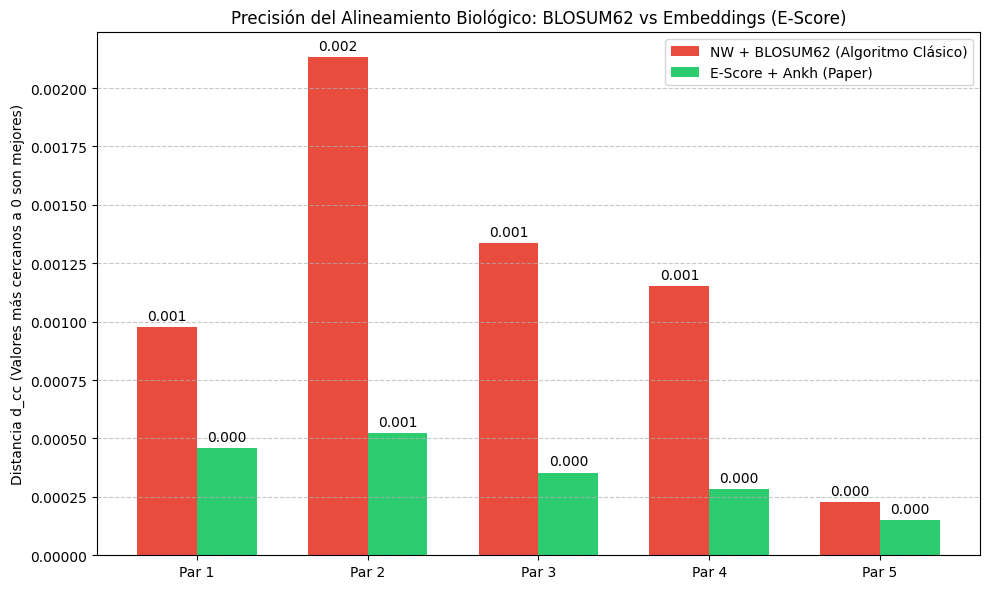

In [18]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import distances_and_extracting_local_alignments as metrics

importlib.reload(metrics)

alineamientos = []
errores_nw_dcc = []
errores_es_dcc = []
labels = []

print("Alineamientos comparativos\n")

#Limite de n filas
for idx, row in df.head(5).iterrows():

    # 1. Asignación correcta de columnas
    seq1 = row['protein1']
    seq2 = row['protein2']

    true_a1 = row['ref1']
    true_a2 = row['ref2']

    # 2. Needleman-Wunsch (BLOSUM62)
    nw_a1, nw_a2, nw_score = needleman_wunsch(seq1, seq2, gap_penalty=-11)

    # 3. E-Score (Ankh)
    es_a1, es_a2, es_score = escore.affine_global_alignment_escore_and_traceback(
        seq1=seq1,
        seq2=seq2,
        g_open=-0.25,
        g_ext=-0.01,
        model=model,
        tokenizer=tokenizer
    )

    reference_alignment = [true_a1, true_a2]
    nw_alignment = [nw_a1, nw_a2]
    es_alignment = [es_a1, es_a2]

    dist_nw = metrics.d_cc(nw_alignment, reference_alignment)
    dist_es = metrics.d_cc(es_alignment, reference_alignment)

    errores_nw_dcc.append(dist_nw)
    errores_es_dcc.append(dist_es)
    labels.append(f"Par {idx + 1}")

    print(f"Par {idx + 1} completado -> Error NW: {dist_nw:.4f} | Error E-Score: {dist_es:.4f}")

print("\nGráfico de comparación")

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, errores_nw_dcc, width, label='NW + BLOSUM62 (Algoritmo Clásico)', color='#e74c3c')
rects2 = ax.bar(x + width/2, errores_es_dcc, width, label='E-Score + Ankh (Paper)', color='#2ecc71')

ax.set_ylabel('Distancia d_cc (Valores más cercanos a 0 son mejores)')
ax.set_title('Precisión del Alineamiento Biológico: BLOSUM62 vs Embeddings (E-Score)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.show()

In [19]:
import glob
import pandas as pd
import random

archivos_csv = glob.glob("global/*.csv")

dataset_completo = []

for archivo in archivos_csv:
    df_temporal = pd.read_csv(archivo)

    #prueba con n ejemplos
    muestra = df_temporal.sample(n=2, random_state=42)
    dataset_completo.append(muestra)

df_final = pd.concat(dataset_completo, ignore_index=True)

print(f"Total de pares a evaluar: {len(df_final)}")


Total de pares a evaluar: 40


1. Buscando y uniendo datasets...
Total de pares listos para evaluar: 4

2. Iniciando alineamientos (modelo Transformer)
Par 1 completado -> Error NW: 0.0117 | Error E-Score: 0.0037
Par 2 completado -> Error NW: 0.1280 | Error E-Score: 0.1185
Par 3 completado -> Error NW: 0.0000 | Error E-Score: 0.0000
Par 4 completado -> Error NW: 0.0005 | Error E-Score: 0.0003
RESULTADOS DEL BENCHMARK
Error Promedio Needleman-Wunsch : 0.0350
Error Promedio E-Score (IA)     : 0.0306
3. Generando gráfico


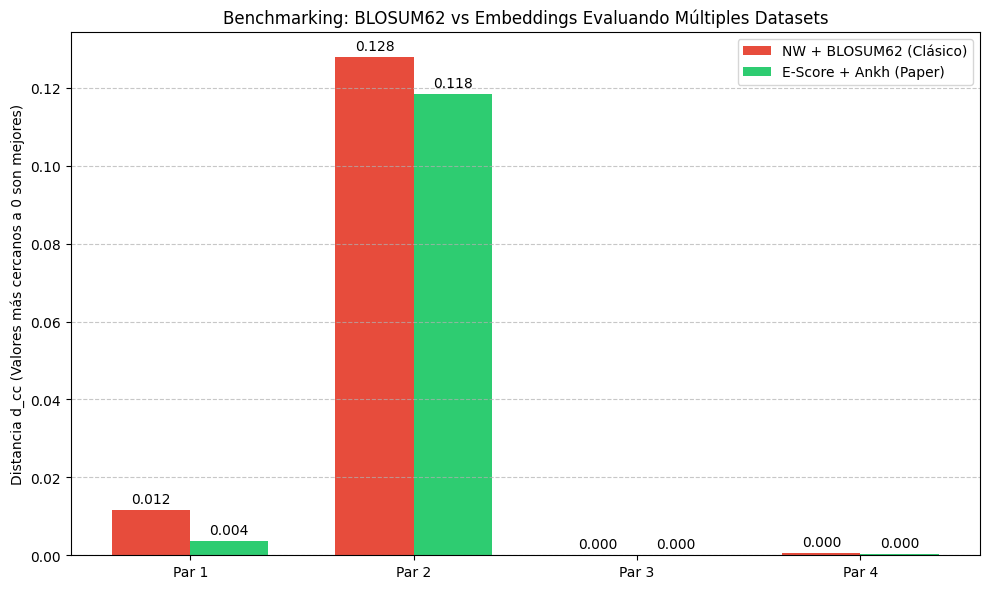

In [20]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import random

import e_score_quick_start as escore
import distances_and_extracting_local_alignments as metrics

importlib.reload(escore)
importlib.reload(metrics)

print("1. Buscando y uniendo datasets...")
archivos_csv = glob.glob("*.csv")

if not archivos_csv:
    print("¡Error! No se encontraron archivos CSV. Asegúrate de haberlos arrastrado a Colab.")
else:
    dataset_completo = []

    for archivo in archivos_csv:
        df_temporal = pd.read_csv(archivo)
        n_muestras = min(2, len(df_temporal))
        muestra = df_temporal.sample(n=n_muestras, random_state=42)
        dataset_completo.append(muestra)

    df_final = pd.concat(dataset_completo, ignore_index=True)

    df_final = df_final.head(10)

    print(f"Total de pares listos para evaluar: {len(df_final)}\n")

    errores_nw_dcc = []
    errores_es_dcc = []
    labels = []

    print("2. Iniciando alineamientos (modelo Transformer)")

    for idx, row in df_final.iterrows():
        seq1 = row['protein1']
        seq2 = row['protein2']
        true_a1 = row['ref1']
        true_a2 = row['ref2']

        # A. Needleman-Wunsch (BLOSUM62)
        nw_a1, nw_a2, nw_score = needleman_wunsch(seq1, seq2, gap_penalty=-11)

        # B. E-Score (Ankh)
        es_a1, es_a2, es_score = escore.affine_global_alignment_escore_and_traceback(
            seq1=seq1, seq2=seq2, g_open=-0.25, g_ext=-0.01, model=model, tokenizer=tokenizer
        )

        # Empaquetar para el script de métricas
        reference_alignment = [true_a1, true_a2]
        nw_alignment = [nw_a1, nw_a2]
        es_alignment = [es_a1, es_a2]

        # C. Cálculo de distancias d_cc
        dist_nw = metrics.d_cc(nw_alignment, reference_alignment)
        dist_es = metrics.d_cc(es_alignment, reference_alignment)

        errores_nw_dcc.append(dist_nw)
        errores_es_dcc.append(dist_es)
        labels.append(f"Par {idx + 1}")

        print(f"Par {idx + 1} completado -> Error NW: {dist_nw:.4f} | Error E-Score: {dist_es:.4f}")

    #BENCHMARK
    promedio_nw = np.mean(errores_nw_dcc)
    promedio_es = np.mean(errores_es_dcc)

    print("RESULTADOS DEL BENCHMARK")
    print(f"Error Promedio Needleman-Wunsch : {promedio_nw:.4f}")
    print(f"Error Promedio E-Score (IA)     : {promedio_es:.4f}")

    print("3. Generando gráfico")

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(labels)), 6))

    rects1 = ax.bar(x - width/2, errores_nw_dcc, width, label='NW + BLOSUM62 (Clásico)', color='#e74c3c')
    rects2 = ax.bar(x + width/2, errores_es_dcc, width, label='E-Score + Ankh (Paper)', color='#2ecc71')

    ax.set_ylabel('Distancia d_cc (Valores más cercanos a 0 son mejores)')
    ax.set_title('Benchmarking: BLOSUM62 vs Embeddings Evaluando Múltiples Datasets')
    ax.set_xticks(x)
    # Si hay más de 5 pares
    ax.set_xticklabels(labels, rotation=45 if len(labels) > 5 else 0)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    ax.bar_label(rects1, fmt='%.3f', padding=3)
    ax.bar_label(rects2, fmt='%.3f', padding=3)

    fig.tight_layout()
    plt.show()